# Heart Disease Prediction

## Problem Statement
The goal of this notebook is to predict whether a patient is at risk of heart disease using the UCI Heart Disease dataset.

## Workflow
- Load the Cleveland heart disease dataset.
- Clean the data and handle missing values.
- Perform exploratory data analysis (EDA).
- Train binary classification models.
- Evaluate performance using accuracy, ROC-AUC, ROC curve, and confusion matrix.
- Highlight the most influential features for prediction.

In [1]:
import importlib.util
import subprocess
import sys
import warnings

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing = [pip_name for module_name, pip_name in required_packages.items() if importlib.util.find_spec(module_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Dataset Loading
The notebook uses the processed Cleveland file from the UCI Heart Disease dataset. If a local copy exists in the `data` folder, it is used first. Otherwise, the notebook downloads the file from the public UCI repository and stores a local copy for reuse.

In [2]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
raw_path = data_dir / "processed.cleveland.data"
source_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

if raw_path.exists():
    df_raw = pd.read_csv(raw_path, names=columns, na_values="?")
else:
    df_raw = pd.read_csv(source_url, names=columns, na_values="?")
    df_raw.to_csv(raw_path, index=False, header=False)

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Data Cleaning And Preprocessing
The original `num` target stores disease severity from `0` to `4`. For binary classification, values greater than `0` are mapped to `1` (heart disease present) and `0` remains `0` (no heart disease).

In [3]:
df = df_raw.copy()
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns="num")

# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values before imputation:")
print(df.isna().sum().sort_values(ascending=False))  # replaced display()

# Impute missing values
feature_columns = [col for col in df.columns if col != "target"]
imputer = SimpleImputer(strategy="median")
df[feature_columns] = imputer.fit_transform(df[feature_columns])

df["target"] = df["target"].astype(int)

print("Missing values after imputation:", df.isna().sum().sum())
print(df.describe().T)

Missing values before imputation:
ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
oldpeak     0
exang       0
slope       0
target      0
dtype: int64
Missing values after imputation: 0
          count        mean        std    min    25%    50%    75%    max
age       303.0   54.438944   9.038662   29.0   48.0   56.0   61.0   77.0
sex       303.0    0.679868   0.467299    0.0    0.0    1.0    1.0    1.0
cp        303.0    3.158416   0.960126    1.0    3.0    3.0    4.0    4.0
trestbps  303.0  131.689769  17.599748   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.693069  51.776918  126.0  211.0  241.0  275.0  564.0
fbs       303.0    0.148515   0.356198    0.0    0.0    0.0    0.0    1.0
restecg   303.0    0.990099   0.994971    0.0    0.0    1.0    2.0    2.0
thalach   303.0  149.607261  22.875003   71.0  133.5  153.0  166.0  202.0
exang     303.0    0.326733   0.469794    0.0    0.0    

## Exploratory Data Analysis
These plots help inspect the class balance, important numeric distributions, and feature relationships with the target.

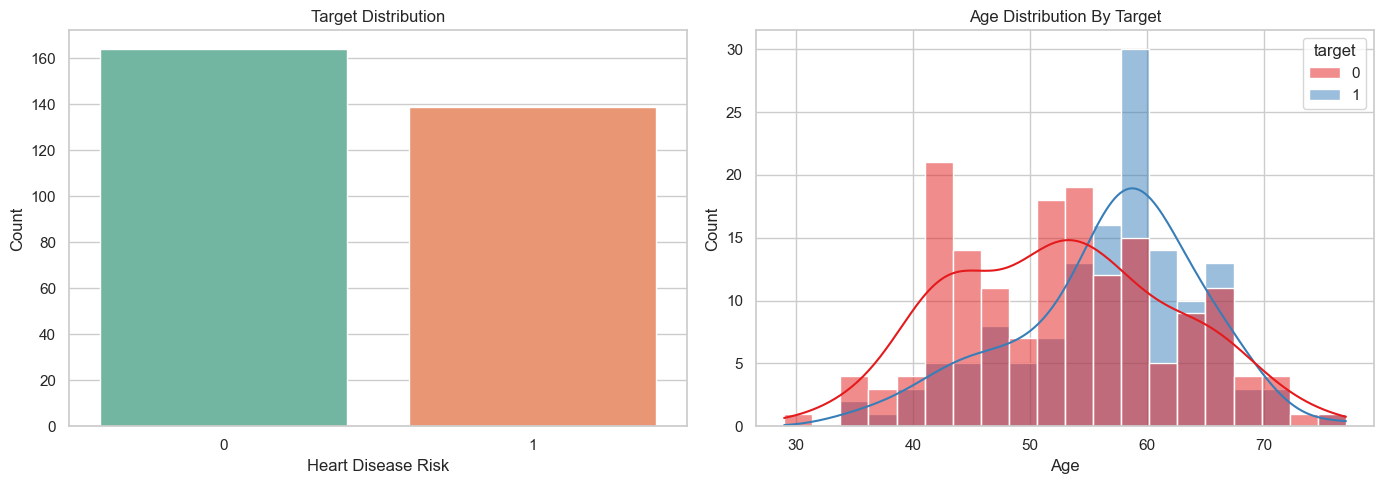

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="target", ax=axes[0], palette="Set2")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Heart Disease Risk")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="age", hue="target", kde=True, bins=20, ax=axes[1], palette="Set1")
axes[1].set_title("Age Distribution By Target")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

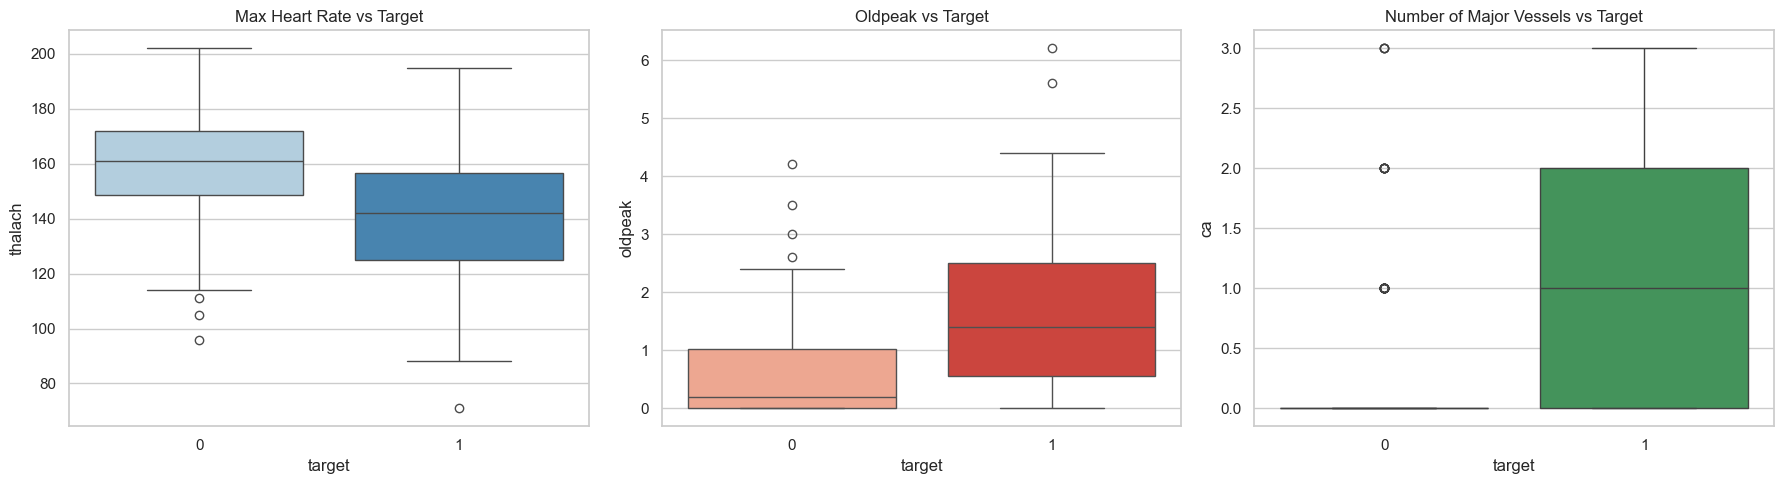

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="target", y="thalach", ax=axes[0], palette="Blues")
axes[0].set_title("Max Heart Rate vs Target")

sns.boxplot(data=df, x="target", y="oldpeak", ax=axes[1], palette="Reds")
axes[1].set_title("Oldpeak vs Target")

sns.boxplot(data=df, x="target", y="ca", ax=axes[2], palette="Greens")
axes[2].set_title("Number of Major Vessels vs Target")

plt.tight_layout()
plt.show()

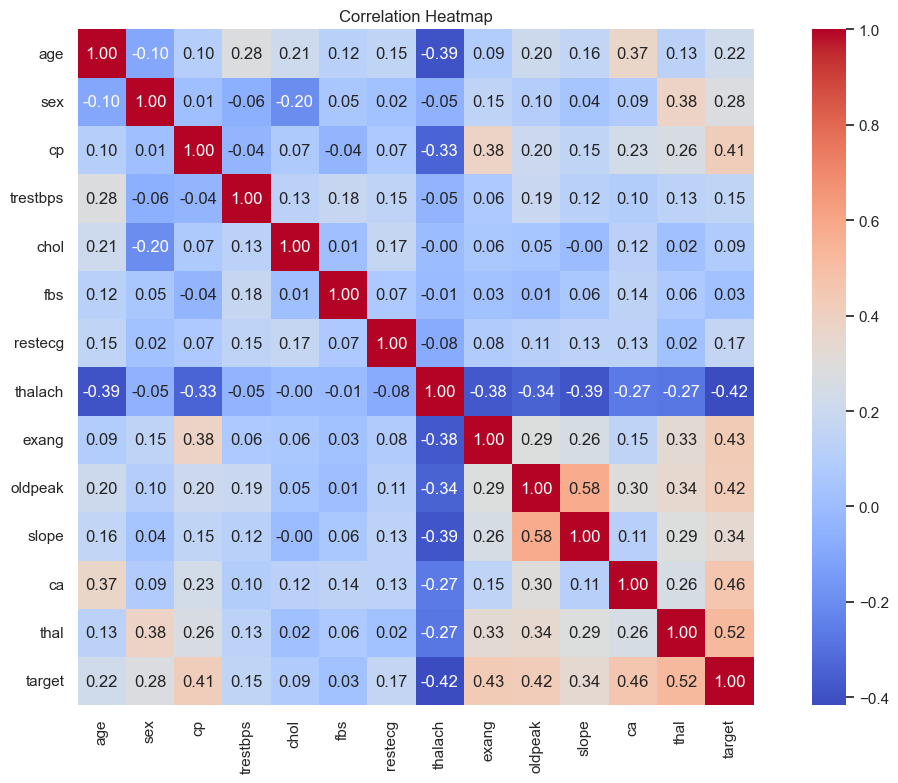

target,0,1
cp,,
1.0,0.695652,0.304348
2.0,0.820000,0.180000
3.0,0.790698,0.209302
4.0,0.270833,0.729167


In [6]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

cp_vs_target = pd.crosstab(df["cp"], df["target"], normalize="index")
cp_vs_target

## Model Training
The notebook trains two baseline classifiers:
- Logistic Regression
- Decision Tree

Logistic Regression provides interpretable coefficients, while the Decision Tree provides non-linear decision boundaries and native feature importance scores.

In [7]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results[model_name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "fpr": fpr,
        "tpr": tpr,
    }

results_df = pd.DataFrame(
    {
        name: {
            "Accuracy": metrics["accuracy"],
            "ROC-AUC": metrics["roc_auc"],
        }
        for name, metrics in results.items()
    }
).T.sort_values(by="ROC-AUC", ascending=False)

results_df

,Accuracy,ROC-AUC
Logistic Regression,0.868852,0.951299
Decision Tree,0.770492,0.877165


## Evaluation
Accuracy summarizes overall classification performance, ROC-AUC measures ranking quality across thresholds, and confusion matrices show how many cases are correctly or incorrectly classified.

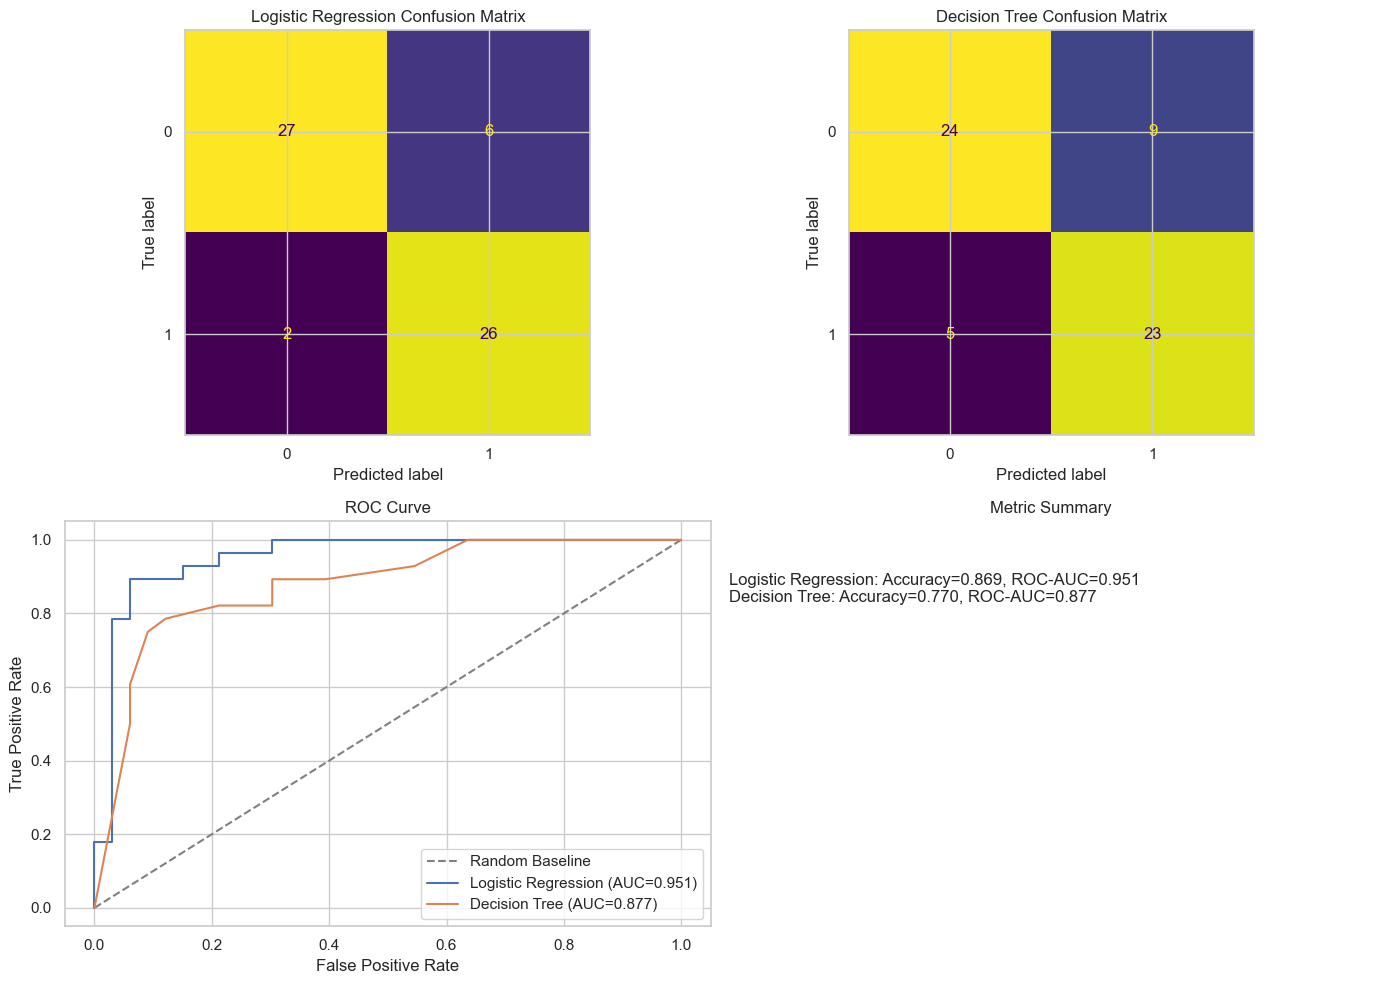

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, metrics) in enumerate(results.items()):
    ConfusionMatrixDisplay(metrics["confusion_matrix"]).plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"{model_name} Confusion Matrix")

# ROC Curve
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline")

for model_name, metrics in results.items():
    axes[2].plot(metrics["fpr"], metrics["tpr"], label=f"{model_name} (AUC={metrics['roc_auc']:.3f})")

axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

# Summary text FIXED
axes[3].axis("off")

summary_text = "\n".join(
    f"{name}: Accuracy={metrics['accuracy']:.3f}, ROC-AUC={metrics['roc_auc']:.3f}"
    for name, metrics in results.items()
)

axes[3].text(0, 0.8, summary_text, fontsize=12)
axes[3].set_title("Metric Summary")

plt.tight_layout()
plt.show()            

## Feature Importance
Logistic Regression coefficients are interpreted by absolute magnitude after scaling. Decision Tree feature importance values indicate which variables contribute most to the split decisions.

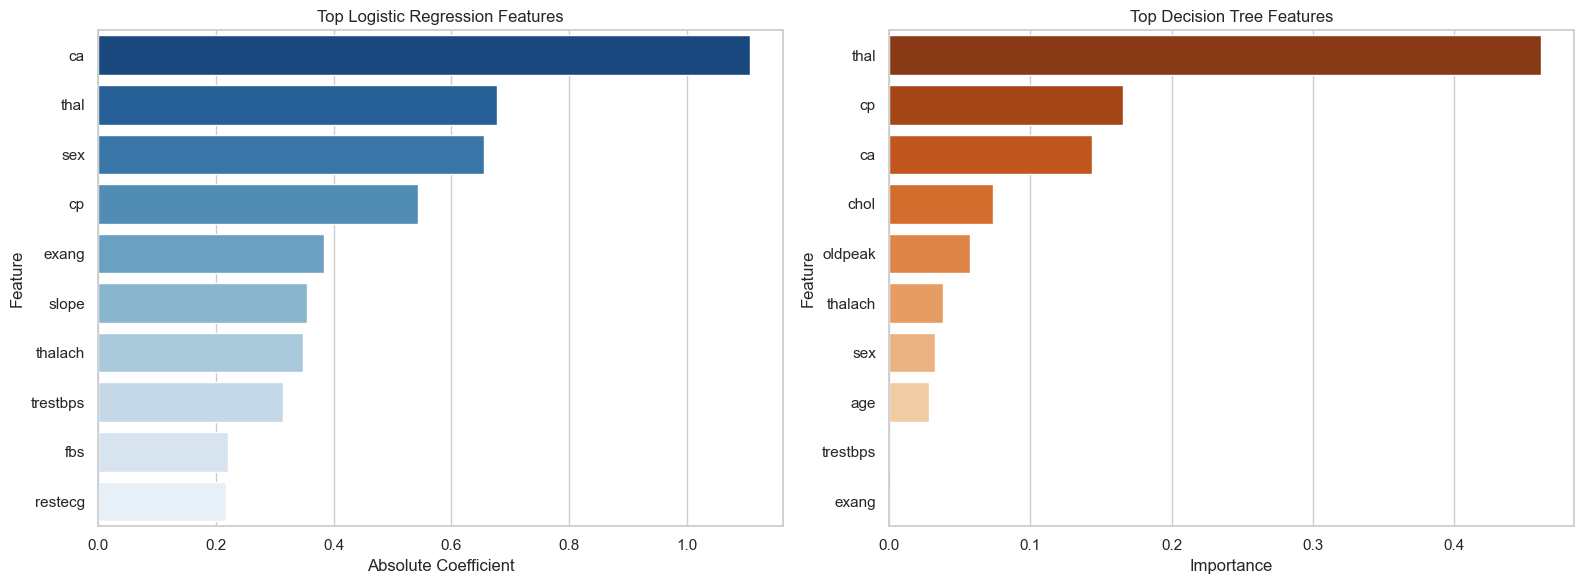

ca          1.107898
thal        0.677821
sex         0.655563
cp          0.543483
exang       0.383642
slope       0.354072
thalach     0.348486
trestbps    0.313655
fbs         0.220560
restecg     0.217329
Name: logistic_abs_coef, dtype: float64

thal        0.461555
cp          0.165488
ca          0.143865
chol        0.073270
oldpeak     0.056987
thalach     0.038263
sex         0.032180
age         0.028392
trestbps    0.000000
exang       0.000000
Name: tree_importance, dtype: float64

In [9]:
logistic_coefficients = pd.Series(
    np.abs(results["Logistic Regression"]["model"].named_steps["model"].coef_[0]),
    index=X.columns,
).sort_values(ascending=False)

tree_importance = pd.Series(
    results["Decision Tree"]["model"].feature_importances_,
    index=X.columns,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=logistic_coefficients.head(10).values, y=logistic_coefficients.head(10).index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top Logistic Regression Features")
axes[0].set_xlabel("Absolute Coefficient")
axes[0].set_ylabel("Feature")

sns.barplot(x=tree_importance.head(10).values, y=tree_importance.head(10).index, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Top Decision Tree Features")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

display(logistic_coefficients.head(10).rename("logistic_abs_coef"))
display(tree_importance.head(10).rename("tree_importance"))

In [10]:
best_model = results_df["ROC-AUC"].idxmax()

print(f"Best model by ROC-AUC: {best_model}")
print("Top logistic regression predictors:", ", ".join(logistic_coefficients.head(5).index))
print("Top decision tree predictors:", ", ".join(tree_importance.head(5).index))

Best model by ROC-AUC: Logistic Regression
Top logistic regression predictors: ca, thal, sex, cp, exang
Top decision tree predictors: thal, cp, ca, chol, oldpeak


## Final Insights
- Missing values are explicitly identified and imputed with the median.
- Binary heart disease prediction is built from the original UCI severity label.
- Model quality is compared using accuracy, ROC-AUC, ROC curve, and confusion matrix.
- The most influential clinical features are extracted from both models for interpretation.

